# Dependency imports

In [1]:
import torch
from torchvision.models import convnext_base

from Training.library import validate
from Training.training import Config, TrainingResources, initClassifierTrainers, trainingLoop
import Training.metrics as m
import Training.plotting as plots

# Non pretrained ConvNeXt-B specific configuration

In [2]:
c = Config("ConvNeXt-B_NoTrain")

#Configure execution to needs
c.purge    = False #Nincs nyúlka!

c.loadBest = False

#Set hyperparams to model
c.learningRate = 2e-5
c.weightDecay  = 5e-2

#c.numClasses = 8
c.batchSize = 16
c.workers = 16


# Initialize resources

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device} device")

model = convnext_base(weights=None)
model.classifier[2] = torch.nn.Linear(model.classifier[2].in_features, out_features=c.numClasses)

TR = TrainingResources(c, model, initClassifierTrainers, device)
TR.load(c)

print(TR.criterion)
print(TR.optimizer)

#Note: After this point only some config changes will apply

Using cuda device
Loaded state
CrossEntropyLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2e-05
    maximize: False
    weight_decay: 0.05
)


# Execute training

In [4]:
# Override training related config if neccesary
c.training = False
c.gpuSleep = 60
c.trainingEpochs = 125

trainingLoop(c, TR, stopAt=0)

Training turned off


In [5]:
display(TR.history)

,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,cm_true_Melanoma_pred_Actinic keratoses,cm_true_Squamous cell carcinoma_pred_Actinic keratoses,cm_true_Vascular lesions_pred_Actinic keratoses,cm_true_Actinic keratoses_pred_Basal cell carcinoma,cm_true_Basal cell carcinoma_pred_Basal cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Basal cell carcinoma,cm_true_Dermatofibroma_pred_Basal cell carcinoma,cm_true_Melanocytic nevi_pred_Basal cell carcinoma,cm_true_Melanoma_pred_Basal cell carcinoma,cm_true_Squamous cell carcinoma_pred_Basal cell carcinoma,cm_true_Vascular lesions_pred_Basal cell carcinoma,cm_true_Actinic keratoses_pred_Benign keratosis-like lesions,cm_true_Basal cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Benign keratosis-like lesions_pred_Benign keratosis-like lesions,cm_true_Dermatofibroma_pred_Benign keratosis-like lesions,cm_true_Melanocytic nevi_pred_Benign keratosis-like lesions,cm_true_Melanoma_pred_Benign keratosis-like lesions,cm_true_Squamous cell carcinoma_pred_Benign keratosis-like lesions,cm_true_Vascular lesions_pred_Benign keratosis-like lesions,cm_true_Actinic keratoses_pred_Dermatofibroma,cm_true_Basal cell carcinoma_pred_Dermatofibroma,cm_true_Benign keratosis-like lesions_pred_Dermatofibroma,cm_true_Dermatofibroma_pred_Dermatofibroma,cm_true_Melanocytic nevi_pred_Dermatofibroma,cm_true_Melanoma_pred_Dermatofibroma,cm_true_Squamous cell carcinoma_pred_Dermatofibroma,cm_true_Vascular lesions_pred_Dermatofibroma,cm_true_Actinic keratoses_pred_Melanocytic nevi,cm_true_Basal cell carcinoma_pred_Melanocytic nevi,cm_true_Benign keratosis-like lesions_pred_Melanocytic nevi,cm_true_Dermatofibroma_pred_Melanocytic nevi,cm_true_Melanocytic nevi_pred_Melanocytic nevi,cm_true_Melanoma_pred_Melanocytic nevi,cm_true_Squamous cell carcinoma_pred_Melanocytic nevi,cm_true_Vascular lesions_pred_Melanocytic nevi,cm_true_Actinic keratoses_pred_Melanoma,cm_true_Basal cell carcinoma_pred_Melanoma,cm_true_Benign keratosis-like lesions_pred_Melanoma,cm_true_Dermatofibroma_pred_Melanoma,cm_true_Melanocytic nevi_pred_Melanoma,cm_true_Melanoma_pred_Melanoma,cm_true_Squamous cell carcinoma_pred_Melanoma,cm_true_Vascular lesions_pred_Melanoma,cm_true_Actinic keratoses_pred_Squamous cell carcinoma,cm_true_Basal cell carcinoma_pred_Squamous cell carcinoma,cm_true_Benign keratosis-like lesions_pred_Squamous cell carcinoma,cm_true_Dermatofibroma_pred_Squamous cell carcinoma,cm_true_Melanocytic nevi_pred_Squamous cell carcinoma,cm_true_Melanoma_pred_Squamous cell carcinoma,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,2.045050,0.273418,1.918675,0.223408,14,40,24,0,138,17,13,1,22,54,23,3,49,29,8,1,20,123,92,17,523,120,22,13,6,33,26,0,49,13,9,4,2,3,22,0,201,52,0,0,16,56,61,1,267,197,6,3,6,17,7,0,9,8,4,0,0,6,7,2,51,16,0,3
1,2,1.929181,0.354111,1.842834,0.340451,17,42,12,1,42,11,10,0,17,102,60,16,302,58,17,10,4,23,20,0,112,39,3,1,4,26,11,0,36,15,1,2,1,11,51,1,544,107,5,4,17,52,54,1,117,164,11,0,26,75,50,4,119,51,14,8,0,1,4,0,15,7,1,0
2,3,1.887272,0.378146,1.656596,0.414788,16,36,21,3,38,15,6,0,32,119,61,4,141,46,9,1,6,40,29,2,91,34,4,2,0,0,0,0,0,0,0,0,3,16,67,2,677,135,10,4,16,50,46,1,140,177,11,1,13,60,28,8,90,23,20,6,0,11,10,3,110,22,2,11
3,4,1.841016,0.389300,1.802645,0.285488,4,18,8,0,19,4,6,0,15,27,19,1,20,

# Plots of learning process

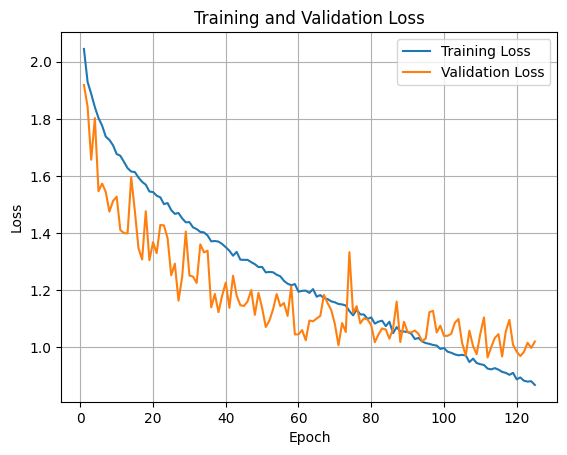

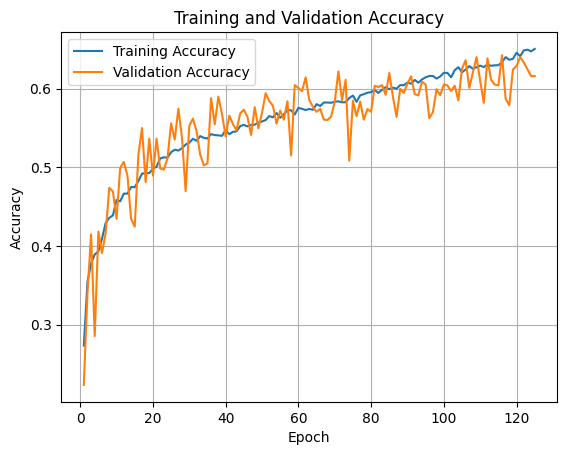

In [6]:
plots.plotTraining(TR.history, TR.plotsFolder)

# Metrics of best model on test data

### Evaluate on test set

In [7]:
#Reload weights with best validation
c.loadBest = True

TR.load(c)

#Evaluate on test set
test_loss, test_acc, CM = validate(TR.model, TR.test_loader, TR.criterion, device)

print(f"Test loss: {test_loss} \t | Test acc: {test_acc}")

Loaded state
Test loss: 0.9936639106179785 	 | Test acc: 0.6208661417322835


### Plots of test results

,accuracy,precision,recall,f1
Actinic keratoses,94.88,31.58,40.91,35.64
Basal cell carcinoma,88.31,55.49,54.65,55.07
Benign keratosis-like lesions,86.34,36.27,42.21,39.02
Dermatofibroma,98.31,29.55,52.00,37.68
Melanocytic nevi,80.08,85.16,73.52,78.92
Melanoma,82.24,50.21,52.32,51.24
Squamous cell carcinoma,95.51,26.42,43.75,32.94
Vascular lesions,98.50,39.66,88.46,54.76


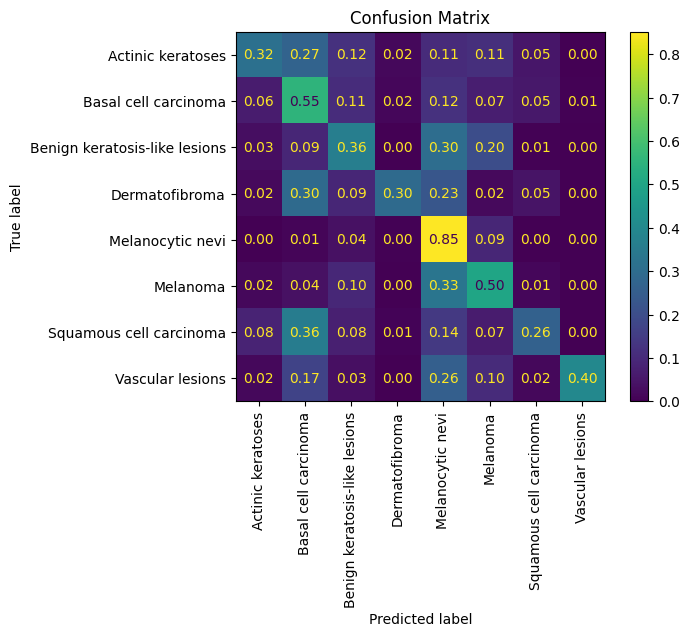

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,36,31,14,2,12,13,6,0
Basal cell carcinoma,21,182,36,5,40,24,18,2
Benign keratosis-like lesions,10,28,111,0,93,62,2,0
Dermatofibroma,1,13,4,13,10,1,2,0
Melanocytic nevi,2,13,43,4,947,103,0,0
Melanoma,8,18,45,0,156,237,7,1
Squamous cell carcinoma,9,38,8,1,15,7,28,0
Vascular lesions,1,10,2,0,15,6,1,23


In [8]:
metrics = plots.deriveMetrics(CM, TR.plotsFolder)
display(metrics)
plots.plotConfusionMatrix(CM, TR.plotsFolder)
display(CM)

Best Melanoma validation @ epoch 124.0


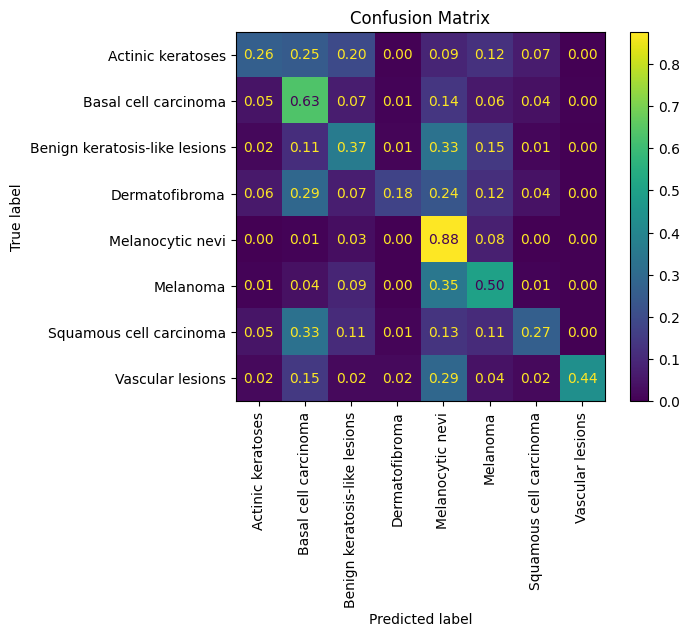

accuracy     82.21
precision    50.19
recall       59.96
f1           54.64
Name: Melanoma, dtype: float64

In [9]:
score = plots.bestMelanoma(TR)
display(score)

### Inspection using captum